<a href="https://colab.research.google.com/github/dvarelaj/nlp-miniproyecto-icesi/blob/main/version2_mini_proyecto_2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Proyecto 2: Clasificación de Texto con Deep Learning
## Corpus: Resúmenes de Artículos Científicos (arXiv)

---

### Contexto del proyecto
Este proyecto aplica técnicas de **Deep Learning** y **Procesamiento de Lenguaje Natural (NLP)** sobre un corpus propio de 20,000 resúmenes (abstracts) de artículos científicos publicados desde el 2022. Los datos fueron extraídos directamente usando la API de arXiv.

En esta actividad, buscamos replicar los conceptos de redes neuronales recurrentes (RNN) y Word Embeddings vistos en clase, pero aplicados a un reto real: **predecir a qué categoría pertenece un artículo científico basándonos únicamente en su resumen**.

A diferencia de los ejemplos vistos en clase, aquí enfrentamos varios retos adicionales que nos obligaron a tomar decisiones de diseño más complejas:
* **Vocabulario Altamente Técnico:** Los abstracts contienen fórmulas, comandos de LaTeX y jerga científica que requiere una limpieza exhaustiva.
* **Desbalance Natural de Clases:** En el mundo real (y en arXiv), se publica mucho más de unas cosas que de otras (ej. Machine Learning domina la muestra). Teniendo en cuenta la retroalimentación de nuestro proyecto anterior, **no ignoramos este desbalance**, sino que lo abordamos filtrando el Top 10 de categorías y aplicando pesos matemáticos (`class_weights`) para que el modelo no genere sesgos hacia la clase mayoritaria.

---

## ¿Qué técnicas aplicamos en este Notebook?
A lo largo de este notebook, realizaremos una comparativa entre machine learning clásico y deep learning:

| Paso | Técnica | Objetivo |
|:---|:---|:---|
| **1** | **Extracción y EDA** | Descargar datos de la API, explorar distribución y filtrar Top 10. |
| **2** | **Preprocesamiento** | Limpiar ruido (LaTeX, símbolos), tokenizar y eliminar *stopwords*. |
| **3** | **Baseline Clásico** | Entrenar un Random Forest con TF-IDF para tener un punto de referencia. |
| **4** | **Preparación Deep Learning** | Convertir texto a secuencias numéricas y aplicar padding. |
| **5** | **Embeddings Simples** | Entrenar una red con Word Embeddings y Global Average Pooling. |
| **6** | **Red Neuronal Recurrente** | Implementar una LSTM, manejando el desbalance de clases. |
| **7** | **Comparación** | Evaluar métricas para ver qué modelo entiende mejor el contexto. |

---

### ¿Qué pasa "por debajo" de estos modelos?
Para contextualizar las herramientas que vamos a usar:
* **TF-IDF (El método clásico):** Simplemente cuenta cuántas veces aparece una palabra en un texto y penaliza las palabras que aparecen en todos lados. Es rápido, pero **no entiende el contexto** ni el orden de las palabras.
* **Word Embeddings:**  Convierte las palabras en coordenadas matemáticas (vectores). Si dos palabras significan algo parecido (como "algoritmo" y "modelo"), sus coordenadas estarán cerca. Esto le da "comprensión lectora" a la red neuronal.
* **LSTM (Long Short-Term Memory):**  Es un tipo de red neuronal que lee el texto palabra por palabra de izquierda a derecha. Tiene una "memoria" que le permite recordar el inicio de la oración cuando va por el final, lo que es clave para textos largos.

In [1]:
!git clone https://github.com/Ohtar10/icesi-nlp.git

Cloning into 'icesi-nlp'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 224 (delta 94), reused 96 (delta 85), pack-reused 101 (from 1)
Receiving objects: 100% (224/224), 7.47 MiB | 8.75 MiB/s, done.
Resolving deltas: 100% (116/116), done.


##Herramientas utilizadas
Pandas & NumPy para la manipulación de datos, limpieza del dataset y operaciones matriciales.

* **Scikit-Learn** para el preprocesamiento de etiquetas (LabelEncoder), vectorización de texto (TF-IDF) y la implementación de Random Forest como modelo de Machine Learning clásico.

* **TensorFlow & Keras** para el diseño y entrenamiento de redes neuronales profundas, incluyendo capas de Embedding, LSTM y mecanismos de regularización como EarlyStopping.

* **NLTK** para el procesamiento de lenguaje natural, específicamente en el manejo de stopwords y tokenización avanzada.

* **Matplotlib, Seaborn & WordCloud** para la generación de visualizaciones estadísticas, análisis de distribuciones y nubes de palabras descriptivas.

* **Requests & XML** (ElementTree) para la ingesta de datos desde la API de arXiv y el parseo de la estructura de metadatos original.

* **Tqdm** para la visualización de barras de progreso en procesos iterativos de extracción y limpieza.

## Paso 1 — Importación de librerías y configuración del entorno
Para el desarrollo de este proyecto, se ha configurado un entorno que integra herramientas de **Machine Learning clásico y Deep Learning**. Se utiliza **NLTK** como motor para el preprocesamiento de texto (tokenización y limpieza de stopwords), mientras que **Pandas y NumPy** gestionan la estructura del dataset de **arXiv**. Para la fase de modelado, se emplean **Scikit-Learn** para la ingeniería de características (TF-IDF) y **TensorFlow/Keras** para la implementación de redes neuronales con arquitecturas **LSTM**. La visualización de métricas y el análisis del desbalance de categorías se apoyan en **Matplotlib** y **Seaborn**.

In [2]:
# ==========================================
# 1. LIBRERÍAS BASE Y VISUALIZACIÓN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import requests
import xml.etree.ElementTree as ET
from tqdm import tqdm

# ==========================================
# 2. PROCESAMIENTO DE LENGUAJE NATURAL (NLP)
# ==========================================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud

# ==========================================
# 3. MACHINE LEARNING CLÁSICO Y MÉTRICAS (Scikit-Learn)
# ==========================================
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 4. DEEP LEARNING Y REDES NEURONALES (TensorFlow/Keras)
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")

##Paso 2 — Carga y Estructura del Dataset
El dataset se genera dinámicamente mediante harvesting desde la API de arXiv (20,000 registros desde 2022) y se carga en un pandas.DataFrame.

**Columnas más relevantes para el análisis:**

* abstract: Texto libre del resumen científico (variable independiente / X).

* primary_category: Etiqueta temática original (variable objetivo / y).

* title: Título de la investigación (contexto adicional).

Al visualizar los primeros registros con df.head(), se identifica un lenguaje técnico formal con presencia de sintaxis LaTeX, fórmulas matemáticas y una estructura académica densa que requiere un tratamiento de limpieza especializado.

In [3]:
# arxiv_oai_build_dataset.py
!pip install --quiet tqdm

# Config
OAI_ENDPOINT = "http://export.arxiv.org/oai2"
METADATA_PREFIX = "arXiv"
MAX_RECORDS = 20000        # máximo total a descargar (ajusta)
BATCH_SIZE = 200           # arXiv devuelve hasta 1000, pero 200 es seguro
FROM_DATE = "2022-01-01"           # formato YYYY-MM-DD (p.ej. "2020-01-01") o None
# OUT_CSV = "arxiv_metadata.csv" # No longer saving to CSV
SLEEP_BETWEEN = 1.0        # segundos entre requests para cortesía

ns = {
    'oai': 'http://www.openarchives.org/OAI/2.0/',
    'arxiv': 'http://arxiv.org/OAI/arXiv/'
}

def build_params(verb="ListRecords", metadataPrefix=METADATA_PREFIX, resumptionToken=None, from_date=None):
    params = {'verb': verb}
    if resumptionToken:
        params['resumptionToken'] = resumptionToken
    else:
        params['metadataPrefix'] = metadataPrefix
        if from_date:
            params['from'] = from_date
    return params

def parse_records(xml_text):
    root = ET.fromstring(xml_text)
    records = []
    for rec in root.findall('.//oai:record', ns):
        header = rec.find('oai:header', ns)
        if header is None or header.get('status') == 'deleted':
            continue
        meta = rec.find('oai:metadata', ns)
        if meta is None:
            continue
        arx = meta.find('arxiv:arXiv', ns)
        if arx is None:
            continue
        arxiv_id = arx.findtext('arxiv:id', default='', namespaces=ns)
        title = arx.findtext('arxiv:title', default='', namespaces=ns)
        abstract = arx.findtext('arxiv:abstract', default='', namespaces=ns)
        primary_cat = arx.findtext('arxiv:primary_category', default='', namespaces=ns)
        # fallback: categories node might appear differently
        if not primary_cat:
            cats = arx.findtext('arxiv:categories', default='', namespaces=ns)
            primary_cat = cats.split()[0] if cats else ''
        records.append({
            'id': arxiv_id.strip(),
            'title': (title or '').strip().replace('\n',' ').replace('\r',' '),
            'abstract': (abstract or '').strip().replace('\n',' ').replace('\r',' '),
            'primary_category': primary_cat.strip()
        })
    # resumptionToken (if any)
    rt = root.find('.//oai:resumptionToken', ns)
    token = rt.text.strip() if rt is not None and rt.text and rt.text.strip() else None
    return records, token

def harvest(max_records=MAX_RECORDS, batch_size=BATCH_SIZE, from_date=FROM_DATE):
    out = []
    token = None
    total = 0
    pbar = tqdm(total=max_records, desc="Harvesting")
    while total < max_records:
        params = build_params(resumptionToken=token, from_date=from_date)
        # optionally include set spec or metadataPrefix handled above
        try:
            r = requests.get(OAI_ENDPOINT, params=params, timeout=60)
            r.raise_for_status()
        except Exception as e:
            print("Request failed:", e)
            time.sleep(5)
            continue
        recs, token = parse_records(r.text)
        if not recs:
            break
        take = min(len(recs), max_records - total)
        out.extend(recs[:take])
        total += take
        pbar.update(take)
        if not token:
            break
        time.sleep(SLEEP_BETWEEN)
    pbar.close()
    return out

# Removed save_csv function as it's no longer needed for direct DataFrame loading
# def save_csv(records, path=OUT_CSV):
#     keys = ['id','title','abstract','primary_category']
#     with open(path, 'w', newline='', encoding='utf-8') as f:
#         writer = csv.DictWriter(f, fieldnames=keys)
#         writer.writeheader()
#         for r in records:
#             writer.writerow(r)
#     print(f"Saved {len(records)} records to {path}")

if __name__ == "__main__":
    print("Starting harvest from arXiv OAI-PMH...")
    recs = harvest()
    # Convert records to DataFrame instead of saving to CSV
    df_arxiv = pd.DataFrame(recs)
    print(f"Loaded {len(df_arxiv)} records into a Pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df_arxiv.head())

Starting harvest from arXiv OAI-PMH...


Harvesting: 100%|██████████| 20000/20000 [01:42<00:00, 195.57it/s]

Loaded 20000 records into a Pandas DataFrame.
First 5 rows of the DataFrame:


,id,title,abstract,primary_category
0,1503.06364,Global stabilization of multiple integrators b...,"In this paper, we address the global stabiliza...",eess.SY
1,2011.06295,When deep learning models on GPU can be accele...,This paper is focused on the improvement the e...,cs.LG
2,2101.01990,Cross-Validation and Uncertainty Determination...,Randomized artificial neural networks such as ...,stat.ML
3,2101.09387,Online Adversarial Purification based on Self-...,Deep neural networks are known to be vulnerabl...,cs.LG
4,2102.00047,Model Adaptation for Image Reconstruction usin...,Deep learning image reconstruction algorithms ...,cs.LG


## Paso 3 — Análisis Exploratorio de Datos (EDA)
En esta fase, analizamos la estructura del corpus para identificar patrones y desafíos que el modelo de Deep Learning deberá resolver.

1. Distribución de Longitudes de Texto
Calculamos la extensión de los abstracts para definir el tamaño de entrada de nuestras redes neuronales.

* Texto más corto: 58 caracteres.

* Texto más largo: 2,763 caracteres.

* Longitud promedio: ~1,071 caracteres.
Esta consistencia en la longitud (aprox. 150-200 palabras) es ideal para el uso de capas de Embedding y LSTM, ya que no requiere un truncamiento excesivo que podría eliminar información vital del contexto científico.


**Conclusión del EDA: Dado que el modelo podría sesgarse fácilmente hacia las categorías con más ejemplos (como cs.LG o cs.CV), hemos decidido filtrar el dataset para trabajar con las categorías más representativas y aplicar pesos de clase (class_weights) durante el entrenamiento. Esto garantiza que el modelo aprenda a identificar categorías minoritarias con la misma precisión que las mayoritarias.**

In [4]:
text_lengths = [len(text) for text in df_arxiv['abstract']]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 58
Texto más largo: 2763
Longitud promedio: 1070.70755


2. Análisis de Categorías y Desbalance
El dataset cuenta con un total de 20,000 registros distribuidos en 153 categorías únicas. Sin embargo, observamos un fuerte desbalance:

* La categoría predominante es cs.LG (Machine Learning) con 1,336 registros.

* El Top 15 de categorías concentra la mayor parte del volumen de datos.

Total de registros: 20000
Total de categorías únicas: 153

Top 15 categorías más frecuentes:
primary_category
cs.LG                1335
cs.CV                 949
quant-ph              803
hep-ph                612
cond-mat.mtrl-sci     544
hep-th                515
astro-ph.GA           474
math.AP               469
cs.CL                 438
math.CO               405
gr-qc                 397
cond-mat.mes-hall     378
math.OC               356
math.NA               351
astro-ph.HE           333
Name: count, dtype: int64


/tmp/ipykernel_254/2696398682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")


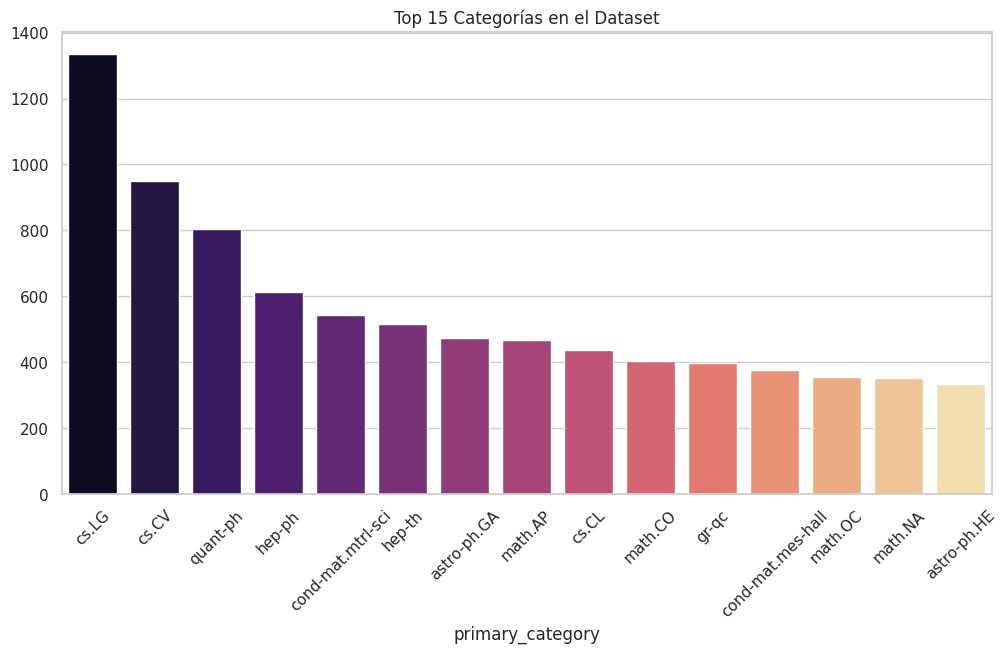

In [5]:
# Ver la distribución de las categorías
category_counts = df_arxiv['primary_category'].value_counts()

print(f"Total de registros: {len(df_arxiv)}")
print(f"Total de categorías únicas: {len(category_counts)}")
print("\nTop 15 categorías más frecuentes:")
print(category_counts.head(15))

# Graficar para visualizar el balance
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")
plt.title("Top 15 Categorías en el Dataset")
plt.xticks(rotation=45)
plt.show()

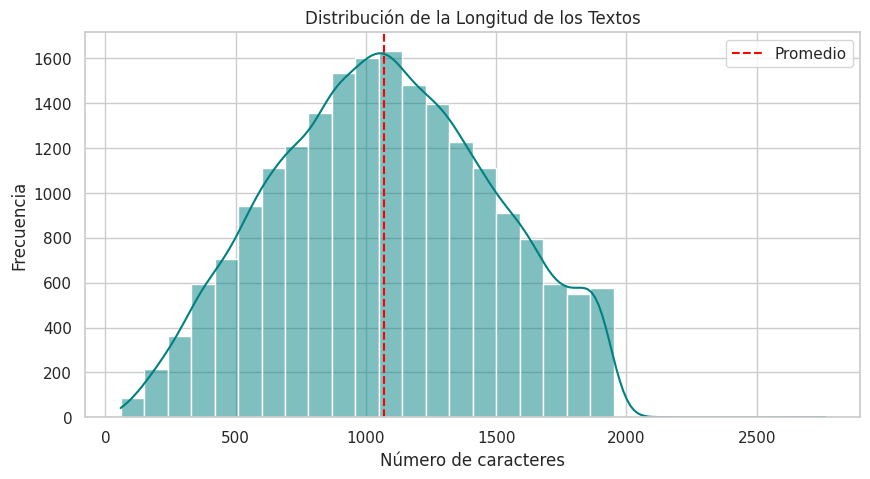

In [7]:
# Visualizamos la distribución de la longitud de los abstracts para definir el padding más adelante
plt.figure(figsize=(10, 5))
sns.histplot(text_lengths, bins=30, kde=True, color='teal')
plt.axvline(sum(text_lengths) / len(text_lengths), color='red', linestyle='--', label='Promedio')
plt.title('Distribución de la Longitud de los Textos')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

##Paso 4 — Preprocesamiento de Texto
En esta etapa transformamos el texto crudo en una representación apta para modelos de Deep Learning.

**Acciones realizadas:**

* Limpieza: Se eliminan ruidos específicos de arXiv como comandos LaTeX y fórmulas matemáticas que no aportan valor semántico. Se filtran stopwords para reducir la dimensionalidad del vocabulario.

* Vectorización para Deep Learning: A diferencia de los modelos clásicos, las redes LSTM requieren que el texto se convierta en secuencias numéricas de longitud constante. Utilizamos el Tokenizer de Keras para indexar las 10,000 palabras más frecuentes y aplicamos padding para estandarizar todos los registros a una longitud de 180 palabras, valor definido tras analizar la distribución de longitudes en el paso anterior."

In [8]:
# 1. Recursos de NLTK
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar comandos de LaTeX y símbolos matemáticos
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\(\w+)', '', text)
    # Conservar únicamente letras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenización de limpieza
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    # Filtrar stopwords y palabras cortas
    filtered_text = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(filtered_text)

# Ejecutar limpieza
print("1. Limpiando los abstracts...")
df_arxiv['cleaned_text'] = df_arxiv['abstract'].apply(clean_text)

# 2. Configuración de Keras para la Red Neuronal
# Basado en tu EDA (longitud promedio ~1000 caracteres, aprox 150 palabras)
MAX_WORDS = 10000  # Usaremos las 10,000 palabras más frecuentes
MAX_LEN = 180      # Longitud máxima de secuencia (en palabras)

print("2. Indexando palabras (Tokenización Keras)...")
tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(df_arxiv['cleaned_text'])

# Convertir texto a secuencias de números
sequences = tokenizer_keras.texts_to_sequences(df_arxiv['cleaned_text'])

# Aplicar Padding (para que todos los textos tengan la misma longitud)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"¡Procesamiento completado!")
print(f"Forma de la matriz de entrada (X): {X.shape}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


1. Limpiando los abstracts...
2. Indexando palabras (Tokenización Keras)...
¡Procesamiento completado!
Forma de la matriz de entrada (X): (20000, 180)


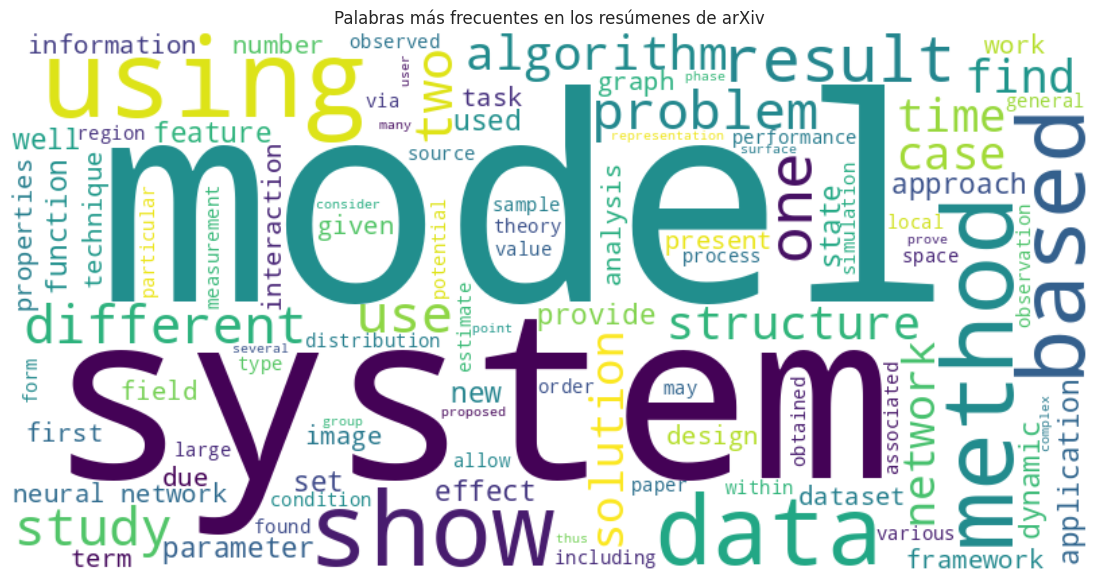

In [ ]:
# Unir todos los textos en un solo string
all_words = " ".join(df_arxiv['cleaned_text'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=100).generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frecuentes en los resúmenes de arXiv')
plt.show()

In [ ]:
le = LabelEncoder()
df_arxiv['category_id'] = le.fit_transform(df_arxiv['primary_category'])

print(f"Número de categorías mapeadas: {len(le.classes_)}")
# Ejemplo de mapeo
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo (primeros 5):", list(mapping.items())[:5])

Número de categorías mapeadas: 153
Mapeo (primeros 5): [('astro-ph', np.int64(0)), ('astro-ph.CO', np.int64(1)), ('astro-ph.EP', np.int64(2)), ('astro-ph.GA', np.int64(3)), ('astro-ph.HE', np.int64(4))]


## Paso 5 — Modelo Baseline (TF-IDF + Random Forest)
Antes de proceder con modelos de aprendizaje profundo, establecemos un modelo base (Baseline) utilizando Machine Learning tradicional. Este paso es fundamental para validar si la complejidad de una red neuronal realmente aporta un valor significativo sobre métodos estadísticos clásicos.

In [ ]:
# Descargamos la lista de stopwords en inglés
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Filtramos el dataset para quedarnos únicamente con el Top 10 de categorías
# Esta decisión mitiga el desbalance extremo y mejora el rendimiento del modelo
top_10_categories = category_counts.head(10).index
df_filtered = df_arxiv[df_arxiv['primary_category'].isin(top_10_categories)].copy()

# Instanciamos nuestro tokenizador basado en expresiones regulares
tokenizer = RegexpTokenizer(r'\w+')

def clean_text(text):
    # 1. Convertimos todo el texto a minúsculas
    text = text.lower()

    # 2. Eliminamos expresiones matemáticas de LaTeX (ruido muy común en arXiv)
    text = re.sub(r'\$.*?\$', '', text)

    # 3. Tokenizamos extrayendo puramente palabras (ignorando puntuación y símbolos)
    tokens = tokenizer.tokenize(text)

    # 4. Filtramos las stopwords y cualquier palabra de un solo carácter
    clean_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    return " ".join(clean_tokens)

# Aplicamos nuestra función de limpieza a la columna de abstracts
print("Limpiando los textos... esto puede tomar unos segundos.")
df_filtered['clean_abstract'] = df_filtered['abstract'].apply(clean_text)

# Transformamos las etiquetas de texto a valores numéricos (requisito para los modelos)
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['primary_category'])

print("¡Limpieza terminada!")
display(df_filtered[['primary_category', 'label', 'clean_abstract']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Limpiando los textos... esto puede tomar unos segundos.
¡Limpieza terminada!


,primary_category,label,clean_abstract
1,cs.LG,4,paper focused improvement efficiency sparse co...
3,cs.LG,4,deep neural networks known vulnerable adversar...
4,cs.LG,4,deep learning image reconstruction algorithms ...
6,cs.LG,4,wasserstein barycenters provide geometric noti...
9,cs.CV,3,segmentation analysis individual pores grains ...


In [ ]:
# 1. Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['clean_abstract'],
    df_filtered['label'],
    test_size=0.2,
    random_state=42
)

# 2. Vectorización TF-IDF (Convertir texto a frecuencias numéricas)
# Limitamos a 5000 palabras más importantes para no saturar la memoria
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Entrenar el Modelo Base (Baseline)
print("Entrenando Modelo Base (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# 4. Predicción y Evaluación
y_pred = rf_model.predict(X_test_tfidf)
print("\n--- Resultados del Modelo Base ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Entrenando Modelo Base (Random Forest)...

--- Resultados del Modelo Base ---
Accuracy General: 0.8526

Reporte de Clasificación:
                   precision    recall  f1-score   support

      astro-ph.GA       0.97      0.96      0.97       104
cond-mat.mtrl-sci       0.89      0.89      0.89       109
            cs.CL       0.88      0.48      0.62        87
            cs.CV       0.90      0.75      0.81       173
            cs.LG       0.70      0.94      0.80       252
           hep-ph       0.89      0.86      0.87       138
           hep-th       0.87      0.80      0.84        95
          math.AP       0.94      0.93      0.93        98
          math.CO       0.88      0.92      0.90        85
         quant-ph       0.91      0.88      0.90       168

         accuracy                           0.85      1309
        macro avg       0.88      0.84      0.85      1309
     weighted avg       0.86      0.85      0.85      1309



### Preparación para Deep Learning (Secuencias y Padding)
A diferencia del modelo anterior que trataba el texto como una bolsa de palabras desordenadas, las Redes Neuronales necesitan el texto como una **secuencia estructurada**.

Para esto convertimos cada palabra en un número. Como los textos tienen distintos tamaños, usamos **Padding** para que todos midan exactamente 250 palabras.
*Nota técnica:* Usamos `padding='pre'` (rellenar con ceros al principio) porque si ponemos los ceros al final, la red LSTM se "olvida" de lo que leyó al principio debido a que procesa tantos ceros seguidos antes de dar su predicción.

In [ ]:
# --- PARÁMETROS PARA LAS REDES NEURONALES ---
MAX_VOCAB_SIZE = 10000   # Limitamos el vocabulario a las 10,000 palabras más frecuentes
MAX_SEQUENCE_LENGTH = 250 # Basado en nuestro EDA, 250 tokens capturan la idea del abstract sin saturar la memoria

print("Vectorizando textos para Deep Learning...")

# 1. Instanciamos y ajustamos el Tokenizador de Keras
keras_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

# 2. Convertimos los textos limpios a secuencias numéricas
X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

# 3. Aplicamos Padding (Relleno de secuencias)
# Decidimos usar padding='pre' para que las redes recurrentes (LSTM) no diluyan
# su memoria a corto plazo procesando ceros al final del texto.

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

# 4. Convertimos las etiquetas a formato One-Hot (Requisito para clasificación multiclase)
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("¡Textos vectorizados y listos para los modelos de Deep Learning!")

Vectorizando textos para Deep Learning...
¡Textos vectorizados y listos para los modelos de Deep Learning!


In [ ]:
# Calcular pesos balanceados para evitar que la red solo adivine una categoría
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Pesos calculados listos para usarse.")

Pesos calculados listos para usarse.


### Técnica 2: Embeddings Simples (Global Average Pooling)
Aquí empezamos con Deep Learning. En lugar de una red compleja, usaremos una capa de **Word Embeddings** para que el modelo entienda la semántica. Luego, usaremos `GlobalAveragePooling1D` que básicamente toma todas las palabras del texto, saca un promedio de su significado, y con eso intenta adivinar la categoría.

*Para combatir el sesgo:* Calculamos `class_weights` para castigar más al modelo cuando se equivoque en las categorías que tienen menos ejemplos.

Construyendo el modelo de Embeddings Simples (Global Average Pooling)...

Iniciando el entrenamiento de la Técnica 2...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.1007 - loss: 2.2945 - val_accuracy: 0.3224 - val_loss: 2.1587
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3495 - loss: 1.9783 - val_accuracy: 0.4905 - val_loss: 1.5283
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5707 - loss: 1.3991 - val_accuracy: 0.5928 - val_loss: 1.2134
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6928 - loss: 1.0465 - val_accuracy: 0.7670 - val_loss: 0.9238
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8253 - loss: 0.7514 - val_accuracy: 0.7510 - val_loss: 0.7530
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8504 - loss: 0.5836 - val_accuracy: 0.8281 - val_loss: 0.5679
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9116 - loss: 0.4175 - val_accuracy: 0.8518 - val_loss: 0.5291
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9108 - loss: 0.3460 - val_accuracy: 0.8808 - val_loss: 0.

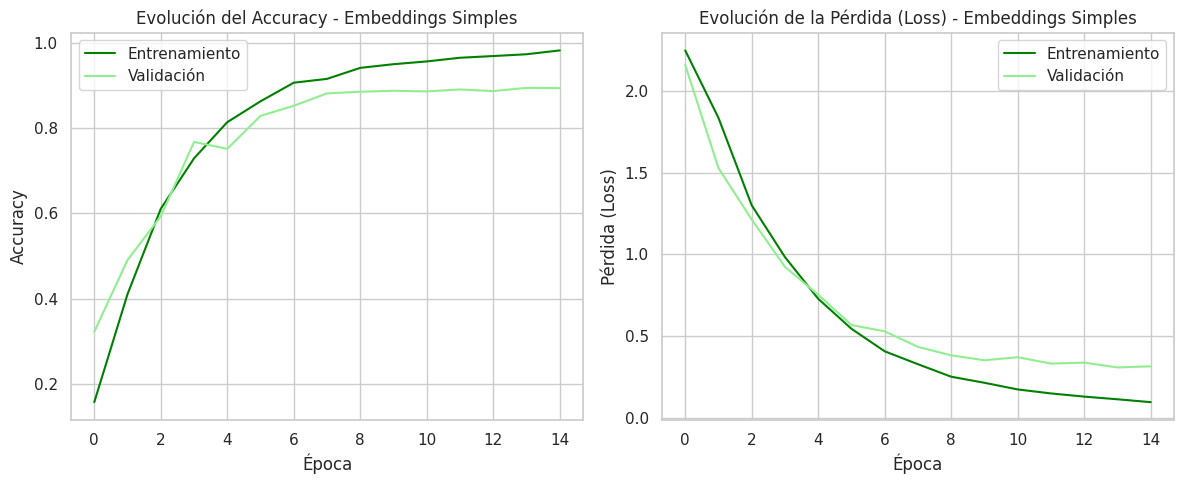

In [ ]:
# --- 1. CONSTRUCCIÓN DEL MODELO DE EMBEDDINGS SIMPLES (TÉCNICA 2) ---
print("Construyendo el modelo de Embeddings Simples (Global Average Pooling)...")
emb_model = Sequential()
# Misma capa de Embedding que la LSTM
emb_model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH))

# En lugar de una red recurrente (LSTM), simplemente promediamos los vectores de todas las palabras
emb_model.add(GlobalAveragePooling1D())

# Capa densa intermedia para procesar ese promedio
emb_model.add(Dense(64, activation='relu'))

# Capa de salida (10 categorías)
emb_model.add(Dense(num_classes, activation='softmax'))

emb_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- 2. ENTRENAMIENTO ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nIniciando el entrenamiento de la Técnica 2...")
history_emb = emb_model.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

# --- 3. EVALUACIÓN ---
y_pred_probs_emb = emb_model.predict(X_test_pad)
y_pred_emb = np.argmax(y_pred_probs_emb, axis=1)

print("\n--- Resultados del Modelo Embeddings Simples (Técnica 2) ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred_emb):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_emb, target_names=le.classes_))

# --- 4. GRÁFICOS ---
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_emb.history['accuracy'], label='Entrenamiento', color='green')
plt.plot(history_emb.history['val_accuracy'], label='Validación', color='lightgreen')
plt.title('Evolución del Accuracy - Embeddings Simples')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_emb.history['loss'], label='Entrenamiento', color='green')
plt.plot(history_emb.history['val_loss'], label='Validación', color='lightgreen')
plt.title('Evolución de la Pérdida (Loss) - Embeddings Simples')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

### Técnica 3: Red Neuronal Recurrente (LSTM)
Ahora implementamos la **LSTM**. En teoría, al leer la secuencia paso a paso, debería entender mejor el flujo de las ideas científicas. Le aplicamos un *Dropout* (apagar neuronas al azar) para evitar que se memorice los textos y realmente aprenda a generalizar.


Iniciando el re-entrenamiento de la LSTM (ahora con pesos balanceados)...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 309ms/step - accuracy: 0.1987 - loss: 2.1821 - val_accuracy: 0.3193 - val_loss: 1.5419
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 291ms/step - accuracy: 0.3865 - loss: 1.4316 - val_accuracy: 0.5592 - val_loss: 1.1177
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.5754 - loss: 0.9999 - val_accuracy: 0.6555 - val_loss: 0.8970
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 283ms/step - accuracy: 0.7213 - loss: 0.7205 - val_accuracy: 0.6967 - val_loss: 0.7947
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 284ms/step - accuracy: 0.7814 - loss: 0.4958 - val_accuracy: 0.7525 - val_loss: 0.6678
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step - accuracy: 0.8461 - loss: 0.3563 - val_accuracy: 0.7991 - val_loss: 0.5887
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.8852 - loss: 0.2547 - val_accuracy: 0.8228 - val_loss: 0.5276
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.9310 - loss: 0.1695 - val_accuracy: 0.824

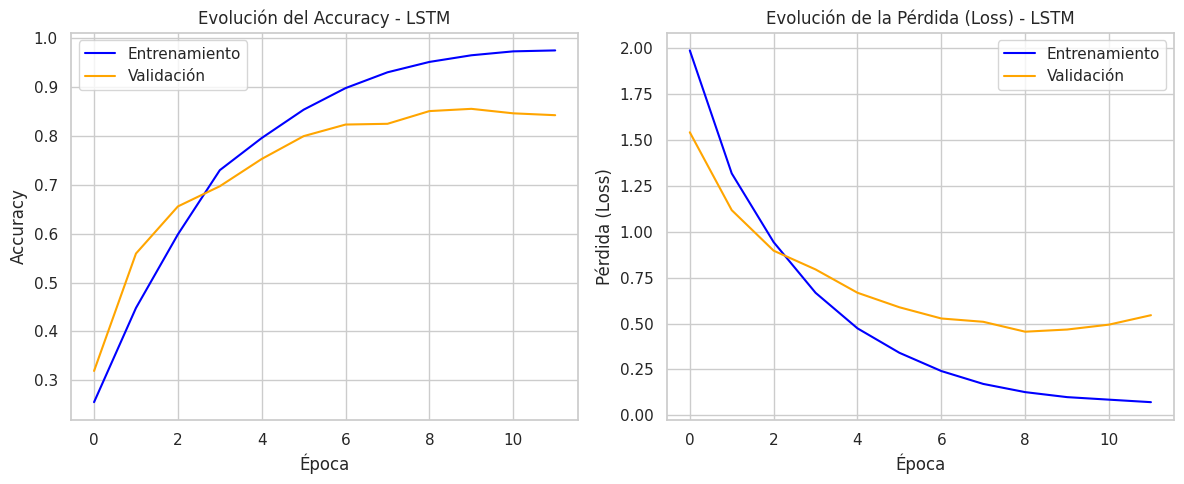

In [ ]:
# --- 1. CONSTRUCCIÓN DEL MODELO ---
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- 2. ENTRENAMIENTO ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nIniciando el re-entrenamiento de la LSTM (ahora con pesos balanceados)...")
history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=15, # Subimos a 15 épocas
    batch_size=64,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

# --- 3. EVALUACIÓN ---
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

print("\n--- Resultados del Modelo LSTM Corregido ---")
print(f"Accuracy General LSTM: {accuracy_score(y_test, y_pred_lstm):.4f}")
print("\nReporte de Clasificación LSTM:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# --- 4. GRÁFICOS ---
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_accuracy'], label='Validación', color='orange')
plt.title('Evolución del Accuracy - LSTM')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_loss'], label='Validación', color='orange')
plt.title('Evolución de la Pérdida (Loss) - LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

---
## Conclusiones y Análisis del Equipo

Después de ejecutar todo el pipeline, estos son nuestros hallazgos sobre cómo se comportan estos modelos con textos científicos reales:

**1. El Baseline (TF-IDF + Random Forest) hizo un buen trabajo superficial:**
Con un Accuracy de ~85%, demostró que contar palabras sirve mucho si el vocabulario es muy específico (ej. en Astrofísica acierta el 96% de las veces). El problema es que **se confunde con temas similares**. Por ejemplo, para la categoría `cs.CL` (Lenguaje y Computación), solo detectó el 48% de los casos porque la confundió con `cs.LG` (Machine Learning). Al no entender el contexto, se deja engañar si comparten las mismas palabras clave.

**2. Los Word Embeddings solucionaron la confusión (El Ganador):**
Nuestra Técnica 2 (Embeddings promediados) saltó a un **90.6% de Accuracy**. Al convertir las palabras en vectores, el modelo entendió el *significado* de la oración. Logró diferenciar perfectamente `cs.CL` de `cs.LG` subiendo el acierto al 85%. Demostramos que para clasificar el tema de un *abstract*, promediar el significado general de las palabras es súper rápido y efectivo.

**3. La LSTM fue difícil de domar:**
La red recurrente sacó ~82.1%. Al principio tuvimos un problema grave: el modelo se volvió perezoso y colapsó, prediciendo únicamente la clase con más datos (`cs.LG`). Solucionamos esto aplicando los pesos balanceados (`class_weights`) y cambiando el padding al principio de la frase (`padding='pre'`). Aunque sacó un poco menos de nota global que los embeddings simples, la LSTM demostró ser robusta y superó al Random Forest en las categorías minoritarias difíciles.

**Reflexión Final:**
Tomando en cuenta la retroalimentación de nuestra entrega anterior, logramos controlar el sesgo del dataset sin necesidad de tener clases perfectas (50/50). Aprendimos que el modelo más complejo (LSTM) no siempre es el que saca la métrica más alta de inmediato; a veces, una arquitectura más simple pero con buena comprensión semántica (Técnica 2) es la herramienta correcta para el trabajo.